# Telecom Customer Churn — Exploratory Data Analysis

**Goal:** Understand *why* customers leave a telecom provider and *which customer segments* are most at risk, using
exploratory data analysis (EDA) in Python and Pandas.

**Dataset:** [IBM Telco Customer Churn](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113) —
7,043 customers, 21 attributes (demographics, account info, services subscribed, billing, and churn status).

**Key business question:** *What patterns in customer profile, contract terms, and billing correlate with churn,
and where should retention efforts focus?*

---
### Contents
1. [Data loading & first look](#1)
2. [Data cleaning](#2)
3. [Churn overview](#3)
4. [Demographics vs. churn](#4)
5. [Tenure & contract vs. churn](#5)
6. [Services vs. churn](#6)
7. [Billing & charges vs. churn](#7)
8. [Correlation analysis](#8)
9. [Key insights & recommendations](#9)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Palette: churn is treated as a status (retained vs. churned), everything
# else uses a fixed categorical order so colors are never reassigned per chart.
COLOR_RETAINED = "#0ca30c"   # good
COLOR_CHURNED = "#d03b3b"    # critical
CHURN_PALETTE = {"No": COLOR_RETAINED, "Yes": COLOR_CHURNED}
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]


<a id="1"></a>\n## 1. Data loading & first look

In [2]:
df = pd.read_csv("../data/telco_customer_churn.csv")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()


Rows: 7,043  |  Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a id="2"></a>\n## 2. Data cleaning\n\nA few known issues with this dataset:\n- `TotalCharges` is stored as text and has blank strings for brand-new customers (`tenure == 0`).\n- `SeniorCitizen` is encoded as `0`/`1` instead of `No`/`Yes`, inconsistent with the other flag columns.\n- `customerID` is a unique identifier with no analytical value.

In [5]:
# TotalCharges: coerce to numeric; blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


Missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
# These are all customers with tenure == 0 (just signed up, no bill yet) -> fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Consistent Yes/No encoding for SeniorCitizen
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Drop the identifier column - not useful for analysis
df = df.drop(columns=["customerID"])

# Sanity check: no missing values left, no duplicate rows
print("Remaining nulls:\n", df.isna().sum()[df.isna().sum() > 0])
print("Duplicate rows:", df.duplicated().sum())
df.shape


Remaining nulls:
 Series([], dtype: int64)
Duplicate rows: 22


(7043, 20)

<a id="3"></a>\n## 3. Churn overview

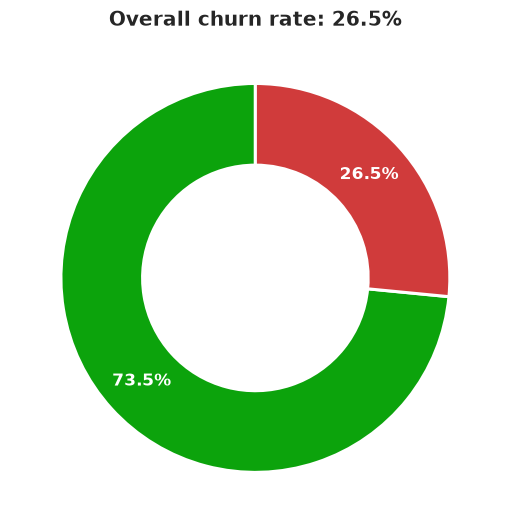

1,869 of 7,043 customers churned (26.5%).


In [7]:
churn_counts = df["Churn"].value_counts()
churn_rate = churn_counts["Yes"] / churn_counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 5))
wedges, _, autotexts = ax.pie(
    churn_counts.reindex(["No", "Yes"]),
    labels=["Retained", "Churned"],
    colors=[COLOR_RETAINED, COLOR_CHURNED],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    pctdistance=0.79,
    textprops={"fontsize": 11, "fontweight": "bold", "color": "white"},
)
ax.set_title(f"Overall churn rate: {churn_rate:.1f}%")
plt.tight_layout()
plt.savefig("../images/01_churn_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{churn_counts['Yes']:,} of {churn_counts.sum():,} customers churned ({churn_rate:.1f}%).")


<a id="4"></a>\n## 4. Demographics vs. churn\n\nDoes churn skew by gender, age (senior citizen), or family status (partner / dependents)?

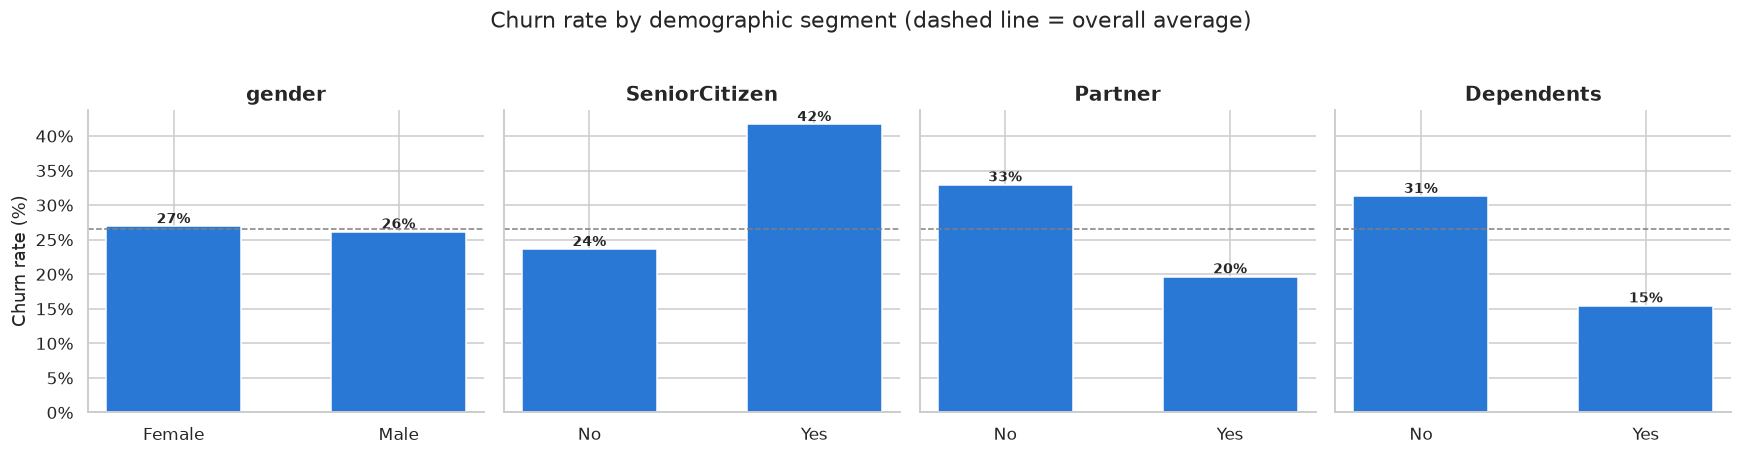

In [8]:
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, col in zip(axes, demo_cols):
    rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    rate = rate.sort_index()
    bars = ax.bar(rate.index.astype(str), rate.values, color=CATEGORICAL[0], width=0.6)
    ax.set_title(col)
    ax.set_ylabel("Churn rate (%)" if col == demo_cols[0] else "")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.axhline(churn_rate, color="grey", linestyle="--", linewidth=1)
    for b, v in zip(bars, rate.values):
        ax.annotate(f"{v:.0f}%", (b.get_x() + b.get_width() / 2, v), ha="center",
                     va="bottom", fontsize=9, fontweight="bold")

fig.suptitle("Churn rate by demographic segment (dashed line = overall average)", y=1.03)
plt.tight_layout()
plt.savefig("../images/02_demographics_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="5"></a>\n## 5. Tenure & contract vs. churn\n\nTenure (months as a customer) and contract type are usually the strongest churn predictors in telecom — let's confirm that here.

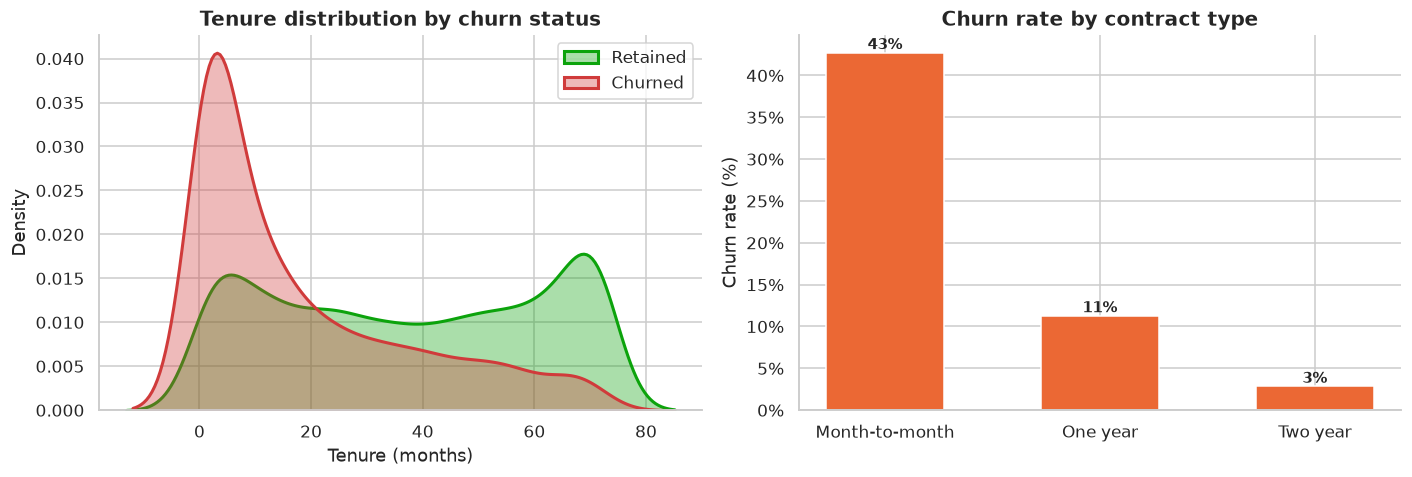

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for churn_val, color, label in [("No", COLOR_RETAINED, "Retained"), ("Yes", COLOR_CHURNED, "Churned")]:
    sns.kdeplot(df.loc[df["Churn"] == churn_val, "tenure"], ax=axes[0], color=color,
                fill=True, alpha=0.35, linewidth=2, label=label)
axes[0].set_title("Tenure distribution by churn status")
axes[0].set_xlabel("Tenure (months)")
axes[0].legend()

contract_rate = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
contract_rate = contract_rate.reindex(["Month-to-month", "One year", "Two year"])
bars = axes[1].bar(contract_rate.index, contract_rate.values, color=CATEGORICAL[1], width=0.55)
axes[1].set_title("Churn rate by contract type")
axes[1].set_ylabel("Churn rate (%)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for b, v in zip(bars, contract_rate.values):
    axes[1].annotate(f"{v:.0f}%", (b.get_x() + b.get_width() / 2, v), ha="center",
                       va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/03_tenure_contract_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("Churn")["tenure"].median())


<a id="6"></a>\n## 6. Services vs. churn\n\nWhich subscribed services (internet type, security/support add-ons) associate with higher or lower churn?

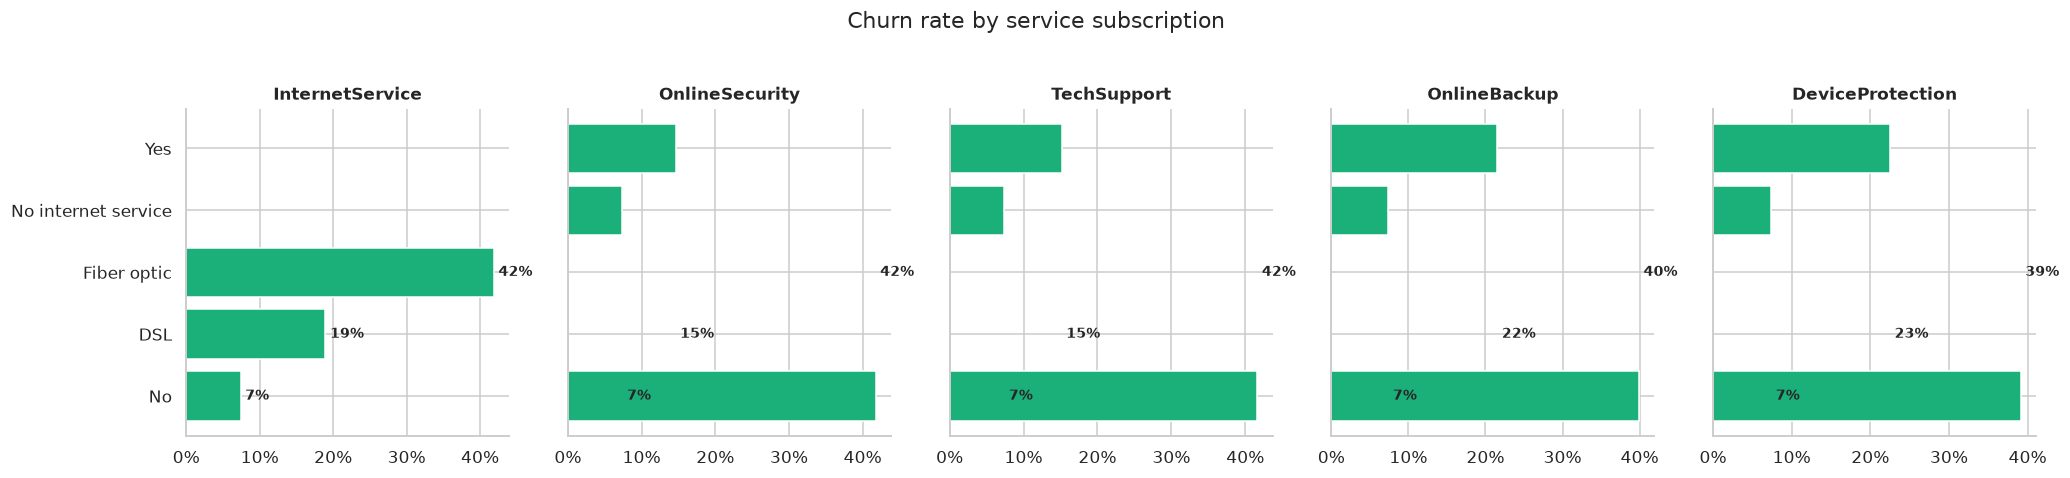

In [10]:
service_cols = ["InternetService", "OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]

fig, axes = plt.subplots(1, len(service_cols), figsize=(19, 4.2), sharey=True)
for ax, col in zip(axes, service_cols):
    rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
    ax.barh(rate.index.astype(str), rate.values, color=CATEGORICAL[2])
    ax.set_title(col, fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    for i, v in enumerate(rate.values):
        ax.annotate(f"{v:.0f}%", (v, i), va="center", ha="left", fontsize=9, fontweight="bold",
                     xytext=(3, 0), textcoords="offset points")

fig.suptitle("Churn rate by service subscription", y=1.03)
plt.tight_layout()
plt.savefig("../images/04_services_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="7"></a>\n## 7. Billing & charges vs. churn

/tmp/ipykernel_1684/1505344143.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"],
/tmp/ipykernel_1684/1505344143.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Retained", "Churned"])


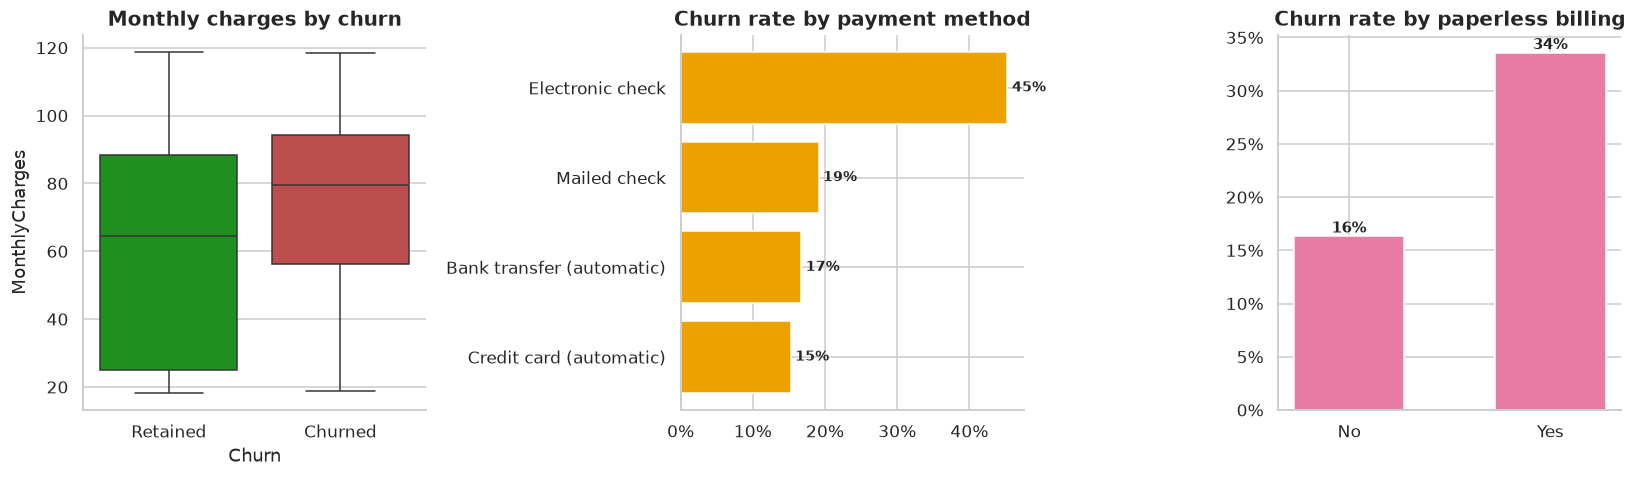

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"],
            palette=CHURN_PALETTE, ax=axes[0])
axes[0].set_title("Monthly charges by churn")
axes[0].set_xticklabels(["Retained", "Churned"])

pay_rate = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
axes[1].barh(pay_rate.index, pay_rate.values, color=CATEGORICAL[3])
axes[1].set_title("Churn rate by payment method")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for i, v in enumerate(pay_rate.values):
    axes[1].annotate(f"{v:.0f}%", (v, i), va="center", ha="left", fontsize=9,
                       fontweight="bold", xytext=(3, 0), textcoords="offset points")

paperless_rate = df.groupby("PaperlessBilling")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
bars = axes[2].bar(paperless_rate.index, paperless_rate.values, color=CATEGORICAL[4], width=0.55)
axes[2].set_title("Churn rate by paperless billing")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for b, v in zip(bars, paperless_rate.values):
    axes[2].annotate(f"{v:.0f}%", (b.get_x() + b.get_width() / 2, v), ha="center",
                       va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/05_billing_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="8"></a>\n## 8. Correlation analysis\n\nEncoding `Churn` as 0/1 lets us look at linear association with the numeric account features.

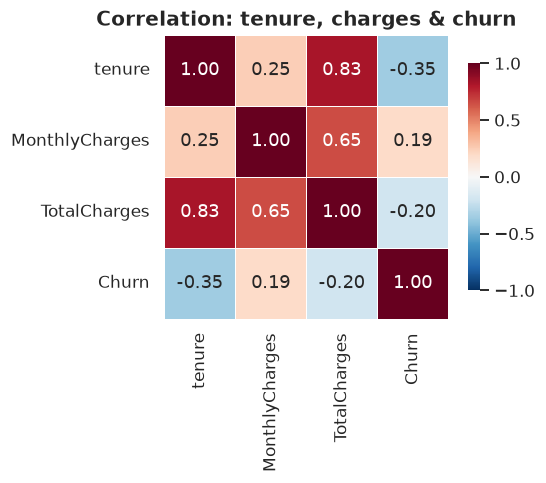

tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
Churn             1.000000
Name: Churn, dtype: float64

In [12]:
corr_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn"] = (df["Churn"] == "Yes").astype(int)

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation: tenure, charges & churn")
plt.tight_layout()
plt.savefig("../images/06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

corr["Churn"].sort_values()


<a id="9"></a>
## 9. Key insights & recommendations

**Findings**
1. **Overall churn rate is ~26.5%** — roughly 1 in 4 customers leaves, a significant revenue-risk base.
2. **Contract type is the single strongest churn driver.** Month-to-month customers churn far more often than
   one-year or two-year contract holders, and churn correlates negatively with tenure — long-tenured customers rarely leave.
3. **New customers are the highest-risk group.** The tenure distribution for churned customers is heavily skewed
   toward the first few months, suggesting the biggest drop-off happens early in the customer lifecycle
   (onboarding / early-experience risk).
4. **Lack of support/security add-ons correlates with churn.** Customers without `OnlineSecurity` or `TechSupport`
   churn at noticeably higher rates than those with them — these services appear to increase "stickiness."
   Fiber-optic internet customers also churn more than DSL customers, which may point to price or service-quality issues.
5. **Billing behavior matters.** Customers paying by **electronic check** and those on **paperless billing** churn
   more than customers on automatic bank transfer / credit card payments — friction or engagement at billing time
   may be a contributing factor.
6. **Higher monthly charges are associated with higher churn**, while `TotalCharges` (a proxy for tenure × spend)
   is *negatively* correlated with churn — consistent with loyal, longer-tenured customers being lower risk.
7. Demographic factors (gender) show **little to no effect** on churn; `SeniorCitizen` customers churn somewhat
   more than non-seniors.

**Recommendations for a retention strategy**
- Prioritize **contract conversion**: incentivize month-to-month customers to move to annual contracts
  (discounts, loyalty pricing) since contract length is the strongest lever identified here.
- Strengthen the **first 3–6 months of the customer lifecycle** with proactive onboarding/check-ins, since early
  tenure is the highest-risk window.
- Bundle or promote **OnlineSecurity / TechSupport** more aggressively, especially for fiber-optic customers, as
  these add-ons associate with materially lower churn.
- Investigate the **electronic check / paperless billing** experience for friction points (e.g., failed payments,
  billing confusion) that could be driving churn.
- Use this EDA as the feature set for a follow-up **predictive churn model** (e.g., logistic regression or
  gradient boosting) to score customers by churn risk and target retention offers proactively.
